In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
circuits_df = pd.read_csv("/Users/bhanureddykotla/JupyterNotebook/EDA-Project/circuits.csv")
constructor_results_df = pd.read_csv("/Users/bhanureddykotla/JupyterNotebook/EDA-Project/constructor_results.csv")
constructor_standings_df = pd.read_csv("/Users/bhanureddykotla/JupyterNotebook/EDA-Project/constructor_standings.csv")
constructors_df = pd.read_csv("/Users/bhanureddykotla/JupyterNotebook/EDA-Project/constructors.csv")
driver_standings_df = pd.read_csv("/Users/bhanureddykotla/JupyterNotebook/EDA-Project/driver_standings.csv")
drivers_df = pd.read_csv("/Users/bhanureddykotla/JupyterNotebook/EDA-Project/drivers.csv")
lap_times_df = pd.read_csv("/Users/bhanureddykotla/JupyterNotebook/EDA-Project/lap_times.csv")
pit_stops_df = pd.read_csv("/Users/bhanureddykotla/JupyterNotebook/EDA-Project/pit_stops.csv")
qualifying_df = pd.read_csv("/Users/bhanureddykotla/JupyterNotebook/EDA-Project/qualifying.csv")
races_df = pd.read_csv("/Users/bhanureddykotla/JupyterNotebook/EDA-Project/races.csv")
results_df = pd.read_csv("/Users/bhanureddykotla/JupyterNotebook/EDA-Project/results.csv")
seasons_df = pd.read_csv("/Users/bhanureddykotla/JupyterNotebook/EDA-Project/seasons.csv")
sprint_results_df = pd.read_csv("/Users/bhanureddykotla/JupyterNotebook/EDA-Project/sprint_results.csv")
status_df = pd.read_csv("/Users/bhanureddykotla/JupyterNotebook/EDA-Project/status.csv")

In [4]:
f1_df = results_df.merge(drivers_df, on="driverId")
f1_df = f1_df.merge(constructors_df, on="constructorId")
f1_df = f1_df.merge(races_df, on="raceId")
f1_df = f1_df.merge(circuits_df, on="circuitId")
f1_df = f1_df.merge(status_df, on="statusId")

MergeError: Passing 'suffixes' which cause duplicate columns {'url_y', 'url_x'} is not allowed.

In [ ]:
print(f1_df.shape)

(26759, 52)


In [ ]:
f1_df.head()

,resultId,raceId,driverId,constructorId,number_x,grid,position,positionText,positionOrder,points,...,fp3_time,quali_date,quali_time,sprint_date,sprint_time,circuitRef,name,location,country,status
0,1,18,1,1,22,1,1,1,1,10.0,...,\N,\N,\N,\N,\N,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,Finished
1,2,18,2,2,3,5,2,2,2,8.0,...,\N,\N,\N,\N,\N,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,Finished
2,3,18,3,3,7,7,3,3,3,6.0,...,\N,\N,\N,\N,\N,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,Finished
3,4,18,4,4,5,11,4,4,4,5.0,...,\N,\N,\N,\N,\N,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,Finished
4,5,18,5,1,23,3,5,5,5,4.0,...,\N,\N,\N,\N,\N,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,Finished


In [ ]:
f1_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26759 entries, 0 to 26758
Data columns (total 52 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   resultId         26759 non-null  int64  
 1   raceId           26759 non-null  int64  
 2   driverId         26759 non-null  int64  
 3   constructorId    26759 non-null  int64  
 4   number_x         26759 non-null  str    
 5   grid             26759 non-null  int64  
 6   position         26759 non-null  str    
 7   positionText     26759 non-null  str    
 8   positionOrder    26759 non-null  int64  
 9   points           26759 non-null  float64
 10  laps             26759 non-null  int64  
 11  time_x           26759 non-null  str    
 12  milliseconds     26759 non-null  str    
 13  fastestLap       26759 non-null  str    
 14  rank             26759 non-null  str    
 15  fastestLapTime   26759 non-null  str    
 16  fastestLapSpeed  26759 non-null  str    
 17  statusId         26759 

In [ ]:
f1_df.describe()

,resultId,raceId,driverId,constructorId,grid,positionOrder,points,laps,statusId,year,round,circuitId
count,26759.000000,26759.000000,26759.000000,26759.000000,26759.000000,26759.000000,26759.000000,26759.000000,26759.000000,26759.000000,26759.000000,26759.000000
mean,13380.977391,551.687283,278.673530,50.180537,11.134796,12.794051,1.987632,46.301768,17.224971,1991.394372,8.511192,23.820808
std,7726.134642,313.265036,282.703039,61.551498,7.202860,7.665951,4.351209,29.496557,26.026104,19.952885,5.070231,19.112002
min,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1950.000000,1.000000,1.000000
25%,6690.500000,300.000000,57.000000,6.000000,5.000000,6.000000,0.000000,23.000000,1.000000,1977.000000,4.000000,9.000000
50%,13380.000000,531.000000,172.000000,25.000000,11.000000,12.000000,0.000000,53.000000,10.000000,1991.000000,8.000000,18.000000
75%,20069.500000,811.000000,399.500000,63.000000,17.000000,18.000000,2.000000,66.000000,14.000000,2009.000000,12.000000,34.000000
max,26764.000000,1144.000000,862.000000,215.000000,34.000000,39.000000,50.000000,200.000000,141.000000,2024.000000,24.000000,80.000000


In [ ]:
f1_df.columns

Index(['resultId', 'raceId', 'driverId', 'constructorId', 'number_x', 'grid',
       'position', 'positionText', 'positionOrder', 'points', 'laps', 'time_x',
       'milliseconds', 'fastestLap', 'rank', 'fastestLapTime',
       'fastestLapSpeed', 'statusId', 'driverRef', 'number_y', 'code',
       'forename', 'surname', 'dob', 'nationality_x', 'url_x',
       'constructorRef', 'name_x', 'nationality_y', 'url_y', 'year', 'round',
       'circuitId', 'name_y', 'date', 'time_y', 'url', 'fp1_date', 'fp1_time',
       'fp2_date', 'fp2_time', 'fp3_date', 'fp3_time', 'quali_date',
       'quali_time', 'sprint_date', 'sprint_time', 'circuitRef', 'name',
       'location', 'country', 'status'],
      dtype='str')

In [ ]:
f1_df.isnull().sum()

resultId           0
raceId             0
driverId           0
constructorId      0
number_x           0
grid               0
position           0
positionText       0
positionOrder      0
points             0
laps               0
time_x             0
milliseconds       0
fastestLap         0
rank               0
fastestLapTime     0
fastestLapSpeed    0
statusId           0
driverRef          0
number_y           0
code               0
forename           0
surname            0
dob                0
nationality_x      0
url_x              0
constructorRef     0
name_x             0
nationality_y      0
url_y              0
year               0
round              0
circuitId          0
name_y             0
date               0
time_y             0
url                0
fp1_date           0
fp1_time           0
fp2_date           0
fp2_time           0
fp3_date           0
fp3_time           0
quali_date         0
quali_time         0
sprint_date        0
sprint_time        0
circuitRef   

In [ ]:
f1_df.isnull().sum().sum()

np.int64(0)

In [ ]:
f1_df[f1_df.isnull().any(axis=1)]

,resultId,raceId,driverId,constructorId,number_x,grid,position,positionText,positionOrder,points,...,fp3_time,quali_date,quali_time,sprint_date,sprint_time,circuitRef,name,location,country,status


In [ ]:
f1_df.duplicated().sum()

np.int64(0)

In [ ]:
wins = f1_df[f1_df["positionOrder"] == 1]
driver_wins = wins.groupby(["forename", "surname"]).size().reset_index(name="wins")
driver_wins = driver_wins.sort_values(by="wins",ascending=False)
print(driver_wins.head(10))

      forename     surname  wins
66       Lewis    Hamilton   105
75     Michael  Schumacher    91
74         Max  Verstappen    63
106  Sebastian      Vettel    53
0        Alain       Prost    51
4       Ayrton       Senna    41
24    Fernando      Alonso    32
81       Nigel     Mansell    31
37      Jackie     Stewart    27
47         Jim       Clark    25


In [ ]:
pole_positions = f1_df[f1_df["grid"] == 1]
driver_poles = pole_positions.groupby(["forename","surname"]).size().reset_index(name="pole_positions")
driver_poles = driver_poles.sort_values(by="pole_positions",ascending=False)
print(driver_poles.head(10))

     forename     surname  pole_positions
64      Lewis    Hamilton             104
72    Michael  Schumacher              68
4      Ayrton       Senna              65
98  Sebastian      Vettel              57
71        Max  Verstappen              40
49        Jim       Clark              34
0       Alain       Prost              33
82      Nigel     Mansell              32
81       Nico     Rosberg              30
58       Juan      Fangio              29


In [ ]:
constructor_season_wins = wins.groupby(['year','name_x']).size().reset_index(name='wins')
constructor_season_wins = constructor_season_wins.rename(columns={'name_x':'name'})
constructor_season_wins = constructor_season_wins.sort_values(by='wins',ascending=False)
print(constructor_season_wins.head(20))

     year      name  wins
272  2023  Red Bull    21
249  2016  Mercedes    19
270  2022  Red Bull    17
245  2014  Mercedes    16
248  2015  Mercedes    16
157  1988   McLaren    15
258  2019  Mercedes    15
208  2004   Ferrari    15
200  2002   Ferrari    15
261  2020  Mercedes    13
244  2013  Red Bull    13
252  2017  Mercedes    12
141  1984   McLaren    12
234  2011  Red Bull    12
183  1996  Williams    12
255  2018  Mercedes    11
267  2021  Red Bull    11
178  1995  Benetton    11
195  2000   Ferrari    10
213  2005   McLaren    10


In [ ]:
champions = constructor_standings_df[constructor_standings_df['position'] == 1]
champions = champions.merge(races_df[['raceId','year']],on='raceId')
champions = champions.merge(constructors_df,on='constructorId')
constructor_titles = champions.groupby('name').size().reset_index(name='championships')
constructor_titles = constructor_titles.sort_values(by='championships',ascending=False)
print(constructor_titles)

               name  championships
9           Ferrari            234
15          McLaren            173
16         Mercedes            145
17         Red Bull            124
22         Williams            114
18          Renault             46
19       Team Lotus             44
2          Benetton             29
11     Lotus-Climax             23
7     Cooper-Climax             20
5             Brawn             17
20          Tyrrell             16
4     Brabham-Repco             16
1               BRM             14
12       Lotus-Ford             12
14       Matra-Ford             11
3           Brabham              6
6            Cooper              4
10           Ligier              4
13            March              3
21          Vanwall              3
0        BMW Sauber              1
8   Cooper-Maserati              1
23             Wolf              1


In [ ]:
driver_champions = driver_standings_df[driver_standings_df['position'] == 1]
driver_champions = driver_champions.merge(races_df[['raceId','year']],on='raceId')
driver_champions = driver_champions.merge(drivers_df,on='driverId')
titles = driver_champions.groupby(['forename','surname']).size().reset_index(name='titles')
titles = titles.sort_values(by='titles',ascending=False)
print(titles)

     forename     surname  titles
35      Lewis    Hamilton     125
42    Michael  Schumacher     121
0       Alain       Prost      79
41        Max  Verstappen      78
58  Sebastian      Vettel      63
..        ...         ...     ...
17  Giancarlo  Fisichella       1
57     Robert      Kubica       1
25       Jean       Behra       1
30       John     Surtees       1
36    Lorenzo     Bandini       1

[62 rows x 3 columns]


In [ ]:
podiums = f1_df[f1_df["positionOrder"] <= 3]
driver_podiums = podiums.groupby(["forename","surname"]).size().reset_index(name="podiums")
driver_podiums = driver_podiums.sort_values(by="podiums",ascending=False)
print(driver_podiums.head(10))

      forename      surname  podiums
111      Lewis     Hamilton      202
132    Michael   Schumacher      155
191  Sebastian       Vettel      122
130        Max   Verstappen      112
1        Alain        Prost      106
46    Fernando       Alonso      106
107       Kimi    Räikkönen      103
10      Ayrton        Senna       80
188     Rubens  Barrichello       68
210   Valtteri       Bottas       67


In [ ]:
races_count = f1_df.groupby(["forename","surname"]).size().reset_index(name="races")
races_count = races_count.sort_values(by="races",ascending=False)
print(races_count.head(10))

      forename      surname  races
256   Fernando       Alonso    404
523      Lewis     Hamilton    356
502       Kimi    Räikkönen    352
754     Rubens  Barrichello    326
411     Jenson       Button    309
578    Michael   Schumacher    308
765  Sebastian       Vettel    300
768     Sergio        Pérez    283
254     Felipe        Massa    271
718   Riccardo      Patrese    257


In [ ]:
circuit_wins = wins.groupby("circuitId").size().reset_index(name="wins")
circuit_wins = circuit_wins.merge(circuits_df[["circuitId","name"]], on="circuitId")
circuit_wins = circuit_wins.sort_values(by="wins",ascending=False)
print(circuit_wins)

    circuitId  wins                                  name
13         14    74          Autodromo Nazionale di Monza
5           6    70                     Circuit de Monaco
8           9    59                   Silverstone Circuit
12         13    57          Circuit de Spa-Francorchamps
6           7    43             Circuit Gilles Villeneuve
..        ...   ...                                   ...
52         54     1                               Le Mans
72         76     1  Autodromo Internazionale del Mugello
40         42     1                             Fair Park
29         31     1                        Donington Park
55         57     1                               Zeltweg

[77 rows x 3 columns]


In [ ]:
drivers_df["nationality"].value_counts().head(10)

nationality
British          166
American         158
Italian           99
French            73
German            50
Brazilian         32
Argentine         24
Swiss             23
Belgian           23
South African     23
Name: count, dtype: int64

In [ ]:
total_races = f1_df.groupby(['forename','surname']).size()
wins_count = wins.groupby(['forename','surname']).size()
win_percentage = (wins_count / total_races * 100).reset_index(name='win_percentage')
win_percentage = win_percentage.sort_values(by='win_percentage',ascending=False)
print(win_percentage.head(10))

    forename     surname  win_percentage
514      Lee     Wallard       50.000000
474     Juan      Fangio       41.379310
83      Bill    Vukovich       40.000000
16   Alberto      Ascari       36.111111
415      Jim       Clark       34.246575
571      Max  Verstappen       30.143541
578  Michael  Schumacher       29.545455
523    Lewis    Hamilton       29.494382
385   Jackie     Stewart       27.000000
62    Ayrton       Senna       25.308642


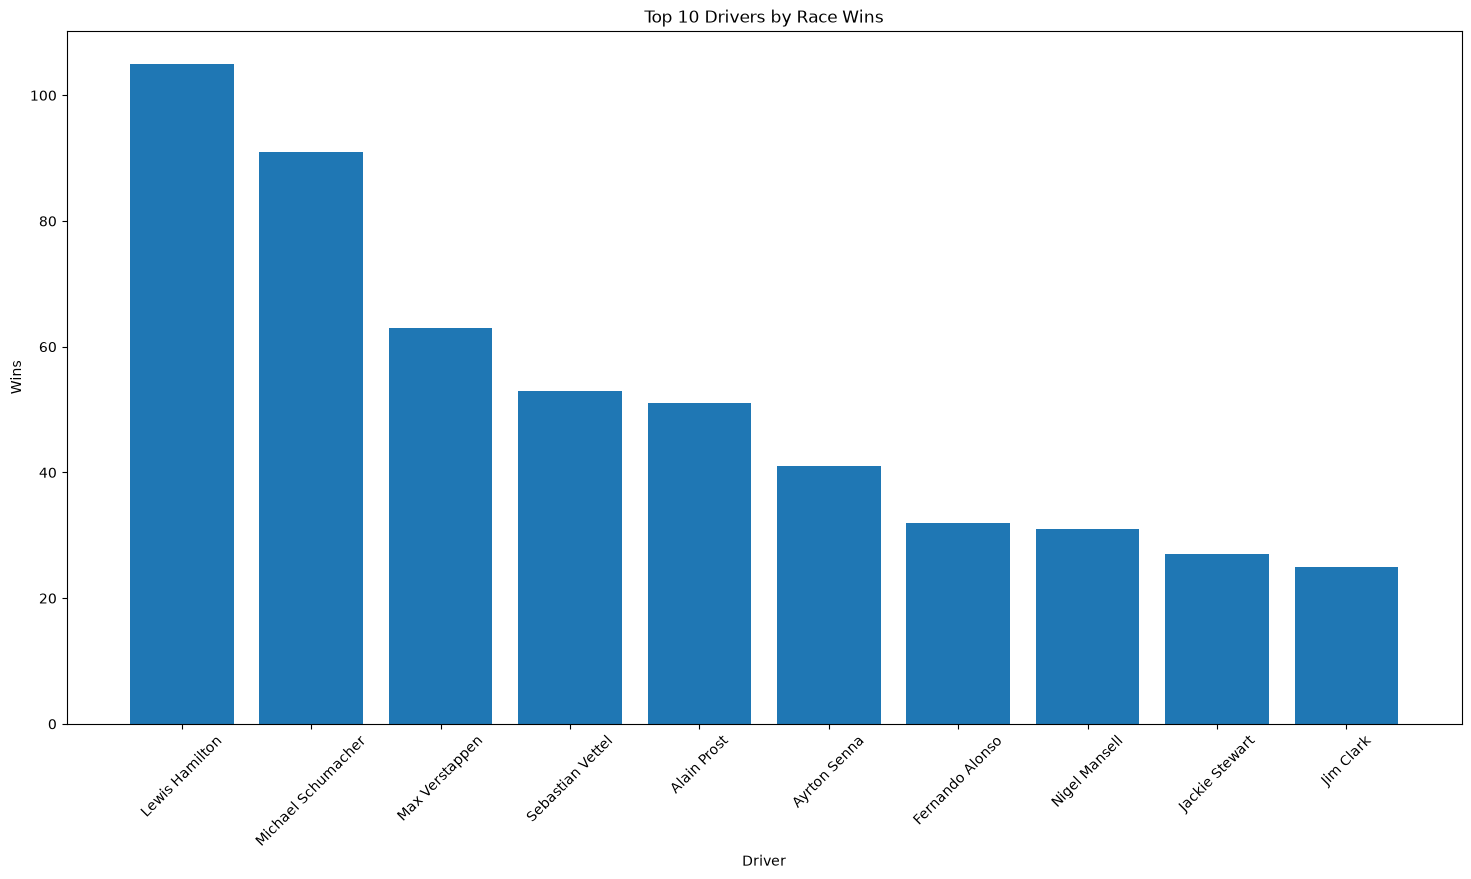

In [ ]:
driver_wins = driver_wins.sort_values(by="wins",ascending=False).head(10)
plt.figure(figsize=(18,9))
plt.bar(driver_wins["forename"] + " " + driver_wins["surname"],driver_wins["wins"])
plt.title("Top 10 Drivers by Race Wins")
plt.xlabel("Driver")
plt.ylabel("Wins")
plt.xticks(rotation=45)
plt.show()

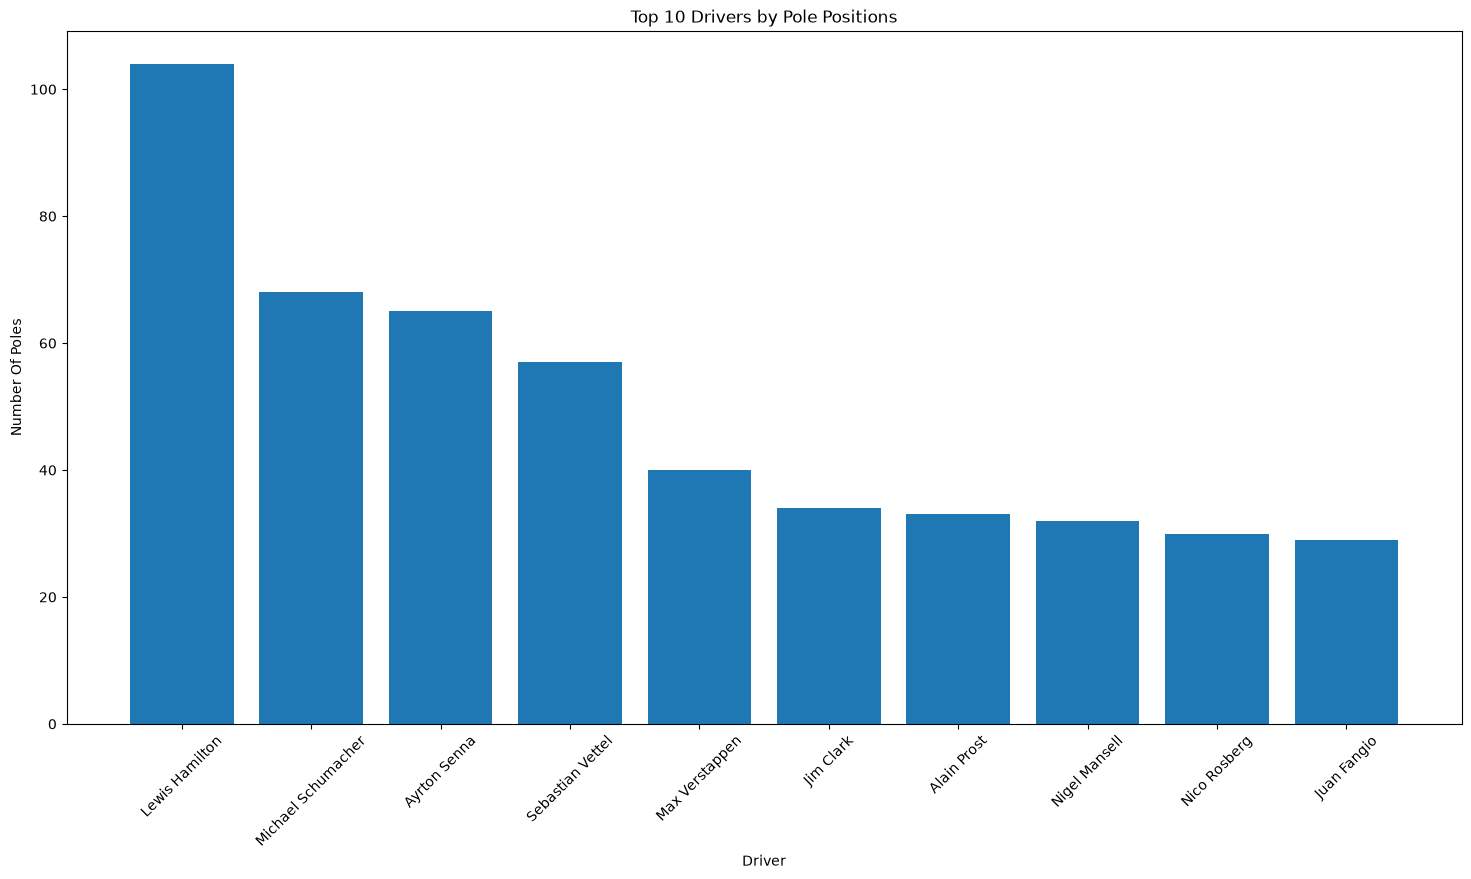

In [ ]:
driver_poles = driver_poles.sort_values(by="pole_positions", ascending=False).head(10)
plt.figure(figsize=(18,9))
plt.bar(driver_poles["forename"] + " " + driver_poles["surname"], driver_poles["pole_positions"])
plt.title("Top 10 Drivers by Pole Positions")
plt.xlabel("Driver")
plt.ylabel("Number Of Poles")
plt.xticks(rotation=45)
plt.show()

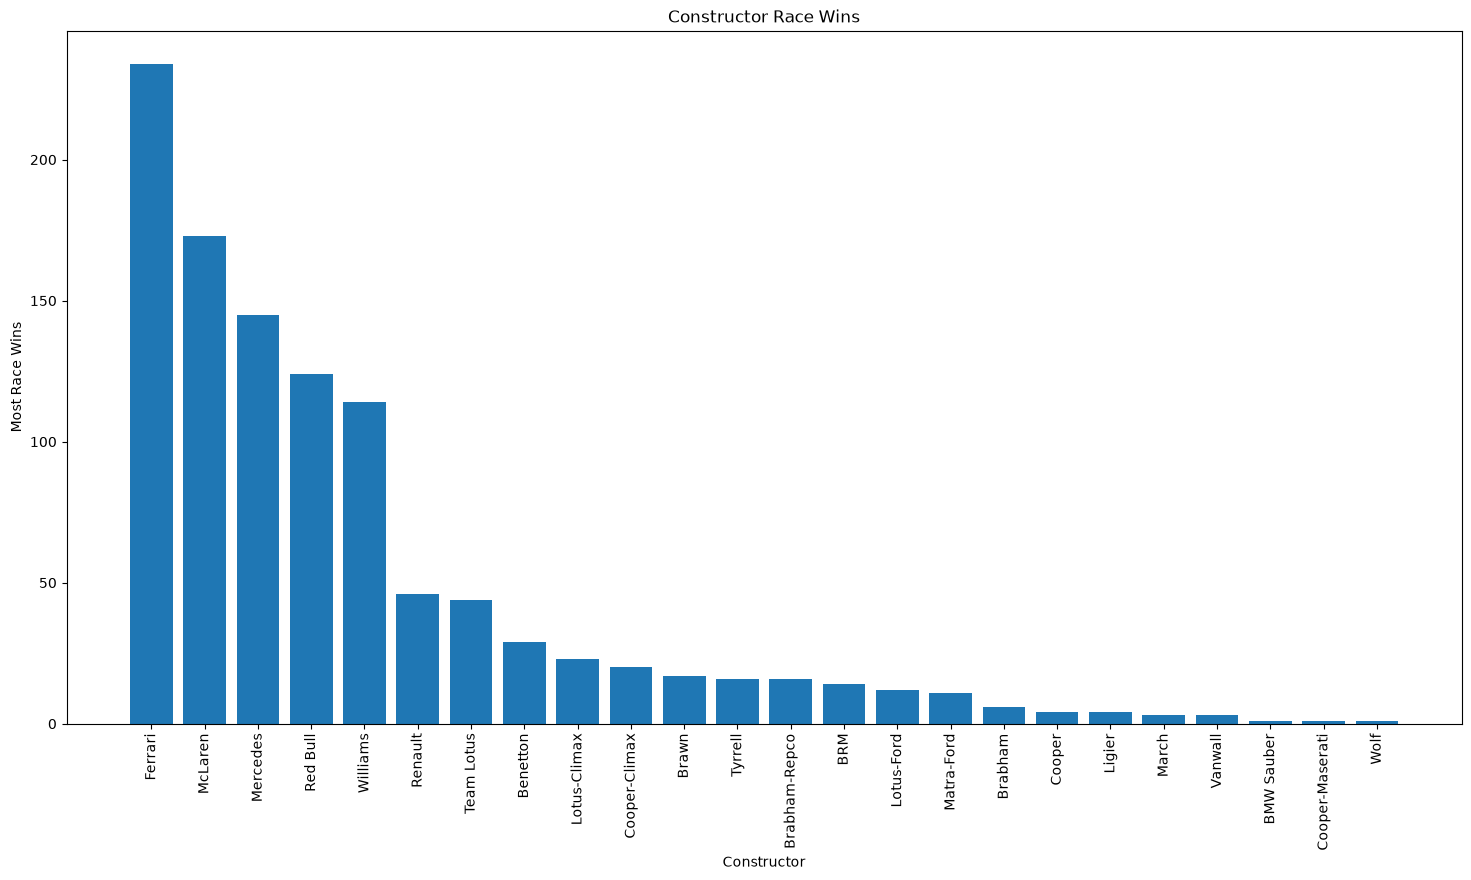

In [ ]:
champions = constructor_standings_df[
    constructor_standings_df["position"] == 1]
champions = champions.merge(constructors_df, on="constructorId")
constructor_titles = champions.groupby("name").size().reset_index(name="championships")
constructor_titles = constructor_titles.sort_values(by='championships',ascending=False)
plt.figure(figsize=(18,9))
plt.bar(constructor_titles["name"],constructor_titles["championships"])
plt.title("Constructor Race Wins")
plt.xlabel("Constructor")
plt.ylabel("Most Race Wins")
plt.xticks(rotation=90)
plt.show()

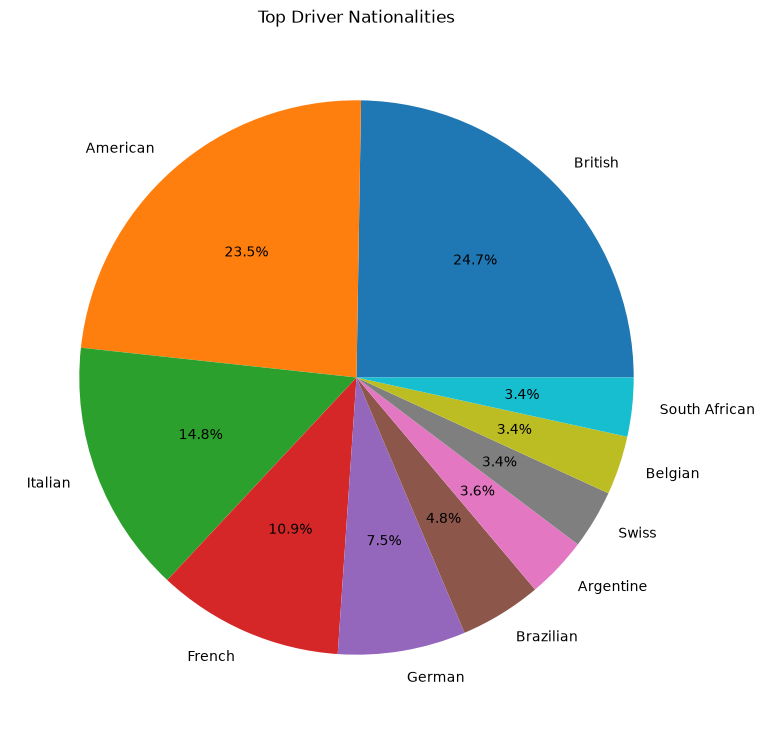

In [ ]:
nationality_counts = drivers_df["nationality"].value_counts().head(10)
plt.figure(figsize=(18,9))
plt.pie(nationality_counts,labels=nationality_counts.index,autopct="%1.1f%%")
plt.title("Top Driver Nationalities")
plt.show()

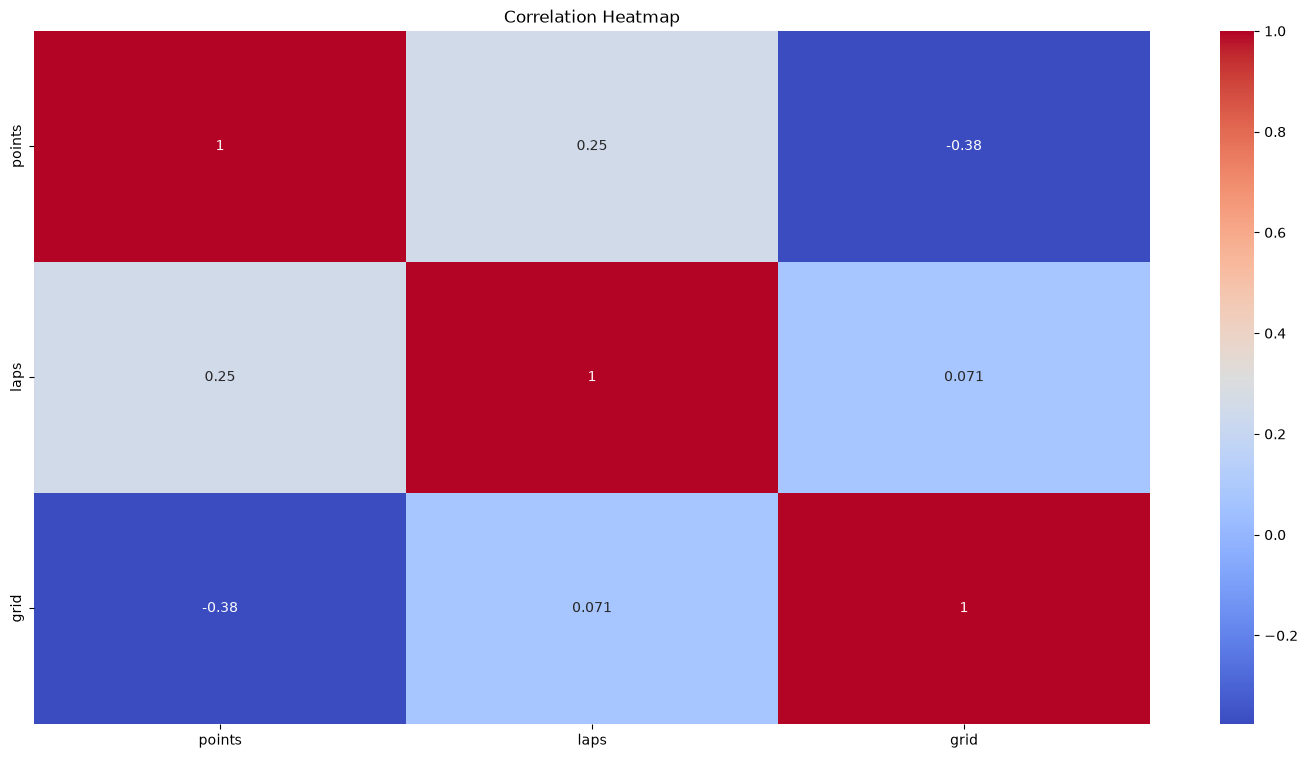

In [ ]:
plt.figure(figsize=(18,9))
sns.heatmap(f1_df[["points","laps","grid"]].corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

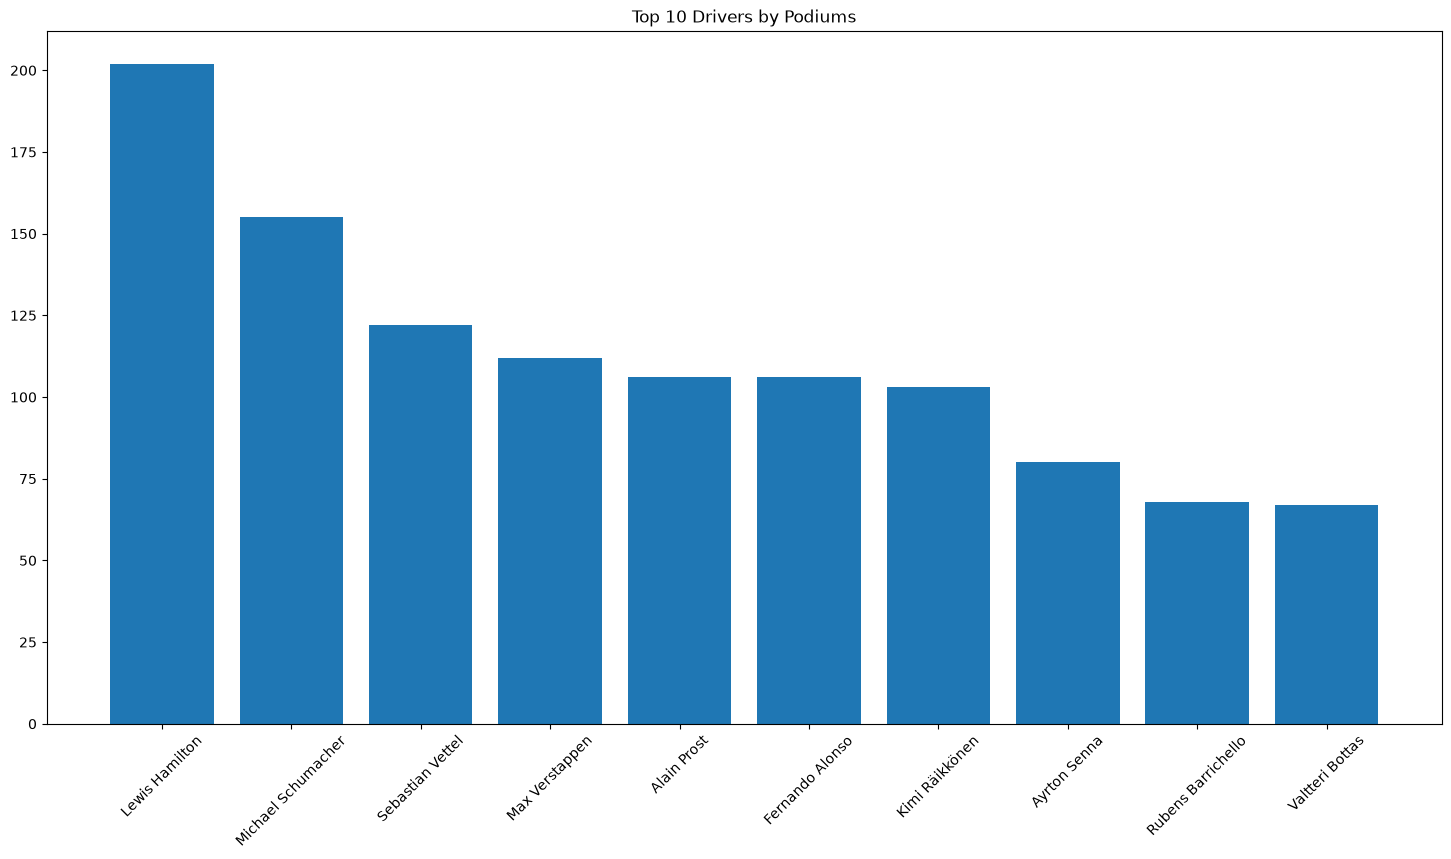

In [ ]:
podiums = f1_df[f1_df["positionOrder"] <= 3]
top_podiums = podiums.groupby(["forename","surname"]).size().reset_index(name="podiums")
top_podiums = top_podiums.sort_values(by="podiums",ascending=False).head(10)
plt.figure(figsize=(18,9))
plt.bar(top_podiums["forename"] + " " + top_podiums["surname"],top_podiums["podiums"])
plt.xticks(rotation=45)
plt.title("Top 10 Drivers by Podiums")
plt.show()